# Siddak Marwaha
# CMSE 381 HW2

### Q 3.7.8

a)

In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
auto = pd.read_csv('Auto.csv')

In [3]:
auto['horsepower'] = pd.to_numeric(auto['horsepower'], errors='coerce')
auto = auto.dropna(subset=['horsepower', 'mpg'])
X = auto['horsepower']
y = auto['mpg']

In [4]:
# Add constant
X_v2 = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X_v2)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           7.03e-81
Time:                        23:51:24   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

i)

The p-value of horsepower is 0, so it is significantly related to mpg.

ii)

The Rsq value being 0.606 indicates that the relationship is moderately strong,

iii)

The coefficient of horsepower is negative, so, the relationship between horsepower and mpg is negative.

iv)

In [5]:
y_pred = results.predict(X_v2)

# Compute RSS
RSS = np.sum((y - y_pred) ** 2)
print("RSS:", round(RSS,2))

# Compute MSE
MSE = RSS / len(y)
print("MSE:", round(MSE,2))


RSS: 9385.92
MSE: 23.94


b)

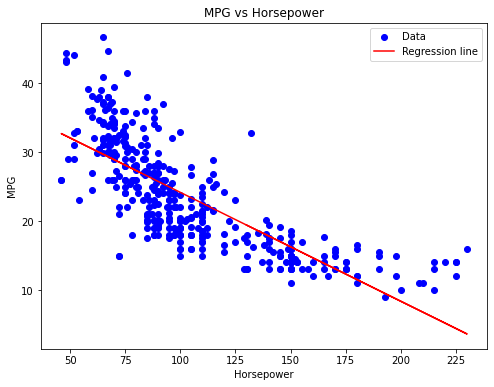

In [6]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X, y, color='blue', label='Data')
ax.plot(X, y_pred, color='red', label='Regression line')

ax.set_xlabel('Horsepower')
ax.set_ylabel('MPG')
ax.set_title('MPG vs Horsepower')
ax.legend()
plt.show()


### Q3.7.13

a)

In [7]:
np.random.seed(1)
x = np.random.normal(0, 1, 100)
x[:5]

array([ 1.62434536, -0.61175641, -0.52817175, -1.07296862,  0.86540763])

b)

In [8]:
eps = np.random.normal(0, np.sqrt(0.25), 100)
eps[:5]

array([-0.22356428,  0.61225385,  0.20174582,  0.29678926, -0.54745592])

c)

In [9]:
y = -1 + 0.5 * x + eps
print("Length of y:", len(y))
print("Beta0: -1, Beta1: 0.5")

Length of y: 100
Beta0: -1, Beta1: 0.5


d)

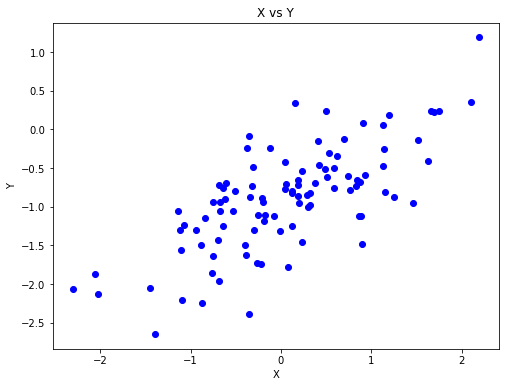

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Data')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('X vs Y')
plt.show()


In this scatterplot, there is a linear relationship between x and y, with some noise represented by eps.

e)

In [11]:
X_v2 = sm.add_constant(x)
model = sm.OLS(y, X_v2)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     107.0
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           2.20e-17
Time:                        23:51:25   Log-Likelihood:                -65.124
No. Observations:                 100   AIC:                             134.2
Df Residuals:                      98   BIC:                             139.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9265      0.047    -19.717      0.0

I see beta_0_predicted is -0.93 which is close to -1 (beta_0) and beta_1_predicted is 0.55 (beta_1) which is close to 0.5. These numbers are different but close since there is noise in the data as we know.

f)

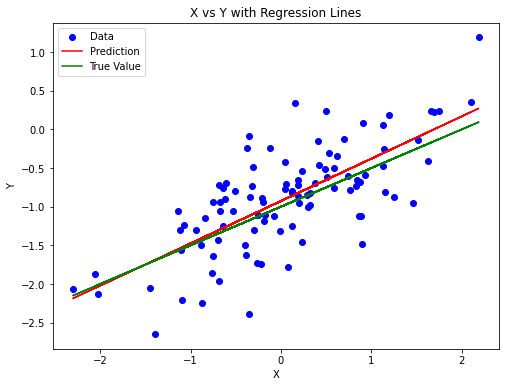

In [12]:
beta0, beta1 = -1, 0.5

plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Data')

y_pred = results.predict(X_v2)
plt.plot(x, y_pred, color='red', label='Prediction')
plt.plot(x, beta0 + beta1 * x, color='green', label='True Value')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('X vs Y with Regression Lines')
plt.legend()
plt.show()

h)

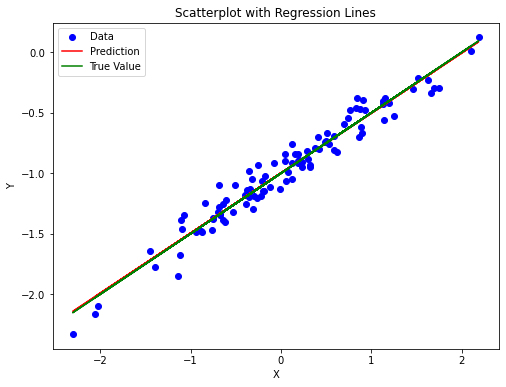

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     1872.
Date:                Sun, 15 Sep 2024   Prob (F-statistic):           1.14e-65
Time:                        23:51:25   Log-Likelihood:                 87.938
No. Observations:                 100   AIC:                            -171.9
Df Residuals:                      98   BIC:                            -166.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9988      0.010    -98.222      0.0

In [13]:
# Less noise: (N(0, 0.1^2))
eps_less = np.random.normal(0, np.sqrt(0.01), 100)
y_less = -1 + 0.5 * x + eps_less

model_less = sm.OLS(y_less, X_v2)
results_less = model_less.fit()

plt.figure(figsize=(8, 6))
plt.scatter(x, y_less, color='blue', label='Data')
plt.plot(x, results_less.predict(X_v2), color='red', label='Prediction')
plt.plot(x, beta0 + beta1 * x, color='green', label='True Value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot with Regression Lines')
plt.legend()
plt.show()

print(results_less.summary())

With less noise, the least squares line is much closer to the True values.

i)

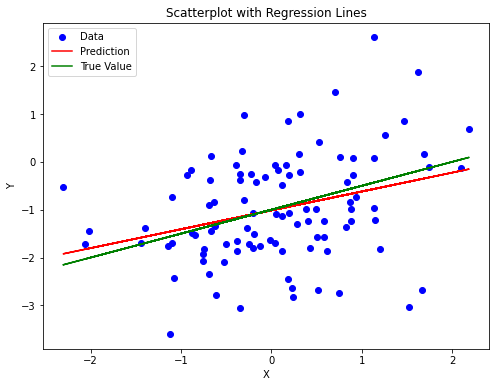

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     10.62
Date:                Sun, 15 Sep 2024   Prob (F-statistic):            0.00154
Time:                        23:51:25   Log-Likelihood:                -147.75
No. Observations:                 100   AIC:                             299.5
Df Residuals:                      98   BIC:                             304.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.0140      0.107     -9.445      0.0

In [14]:
# Generate new eps with more noise (N(0, 1^2))
eps_more = np.random.normal(0, np.sqrt(1), 100)

# Generate new y with more noise
y_more = -1 + 0.5 * x + eps_more

# Fit the model and plot
model_more = sm.OLS(y_more, X_v2)
results_more = model_more.fit()

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(x, y_more, color='blue', label='Data')
plt.plot(x, results_more.predict(X_v2), color='red', label='Prediction')
plt.plot(x, beta0 + beta1 * x, color='green', label='True Value')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatterplot with Regression Lines')
plt.legend()
plt.show()

# Display results
print(results_more.summary())

With more noise, the scatterplot becomes more dispersed, and the least squares line deviates more from the True values.

j)

In [15]:
print("Confidence Intervals for original data:")
print(results.conf_int())
print()
print("Confidence Intervals for less noisy data:")
print(results_less.conf_int())
print()
print("Confidence Intervals for more noisy data:")
print(results_more.conf_int())

Confidence Intervals for original data:
[[-1.01974096 -0.83324551]
 [ 0.44261338  0.65281376]]

Confidence Intervals for less noisy data:
[[-1.01894809 -0.97859004]
 [ 0.4731502   0.51863806]]

Confidence Intervals for more noisy data:
[[-1.22700729 -0.80091614]
 [ 0.15422192  0.63447234]]


The confidence intervals for the less noisy data is narrower, indicating more certainty in beta_0 and beta_1. The confidence intervals for the more noisy data is wider, indicating less certainty.

### Q3.7.1

The null hypotheses for the p-values in Table 3.4 correspond to the claims that each predictor has no effect on sales. Specifically, the hypotheses are:

- H_0 (TV): TV advertising has no effect on sales
- H_0(radio): Radio advertising has no effect on sales.
- H_0(newspaper): Newspaper advertising has no effect on sales.

Based on the p-values:

- The p-values for TV and radio are both <0.0001, indicating that there is a significant positive relationship between advertising on TV and radio and the number of units sold.
- The p-value for newspaper is 0.8599. This means there is not enough evidence of a significant relationship between newspaper advertising and sales.

### Q3.7.9 modified

a)

In [16]:
auto = auto.drop(columns=['name', 'origin'])

correlation_matrix = auto.corr()
print(correlation_matrix)


                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   

              acceleration      year  
mpg               0.423329  0.580541  
cylinders        -0.504683 -0.345647  
displacement     -0.543800 -0.369855  
horsepower       -0.689196 -0.416361  
weight           -0.416839 -0.309120  
acceleration      1.000000  0.290316  
year              0.290316  1.000000  


- mpg is highly negatively correlated to cylinder, displacement and weight
- cylinders are highly correlated to displacement and weight
- displacement is highly related to weight

b)

In [17]:
X = auto.drop(columns=['mpg'])
y = auto['mpg']

X_v2 = sm.add_constant(X)
model = sm.OLS(y, X_v2)
results = model.fit()
print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     272.2
Date:                Sun, 15 Sep 2024   Prob (F-statistic):          3.79e-135
Time:                        23:51:25   Log-Likelihood:                -1036.5
No. Observations:                 392   AIC:                             2087.
Df Residuals:                     385   BIC:                             2115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -14.5353      4.764     -3.051   

c)

Yes, there is a relationship between the predictors and the response. The F-statistic is 272.2 and the p-value of the F-statistic is 0.

d)

Weight and year seemed to have a significantly high relation with the mpg. Weight and year, both have a p-value of 0.000.

e)

The coefficient for year is 0.75, this means that as the year increases (newer cars), the mpg, on average, increases by 0.75